# Cell clustering with HGNN's embeddings.

In [1]:
import numpy as np
import seaborn as sns
from umap import UMAP
import pandas as pd
import json
import sys
import matplotlib.pyplot as plt
from scoit.cell_analysis import *


## sc-GEM

In [ ]:
def plot_embedding(data, loss, cell_stage):
    embedding_dir = f'./embeddings/hgnn/{data}-{loss}'
    cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
    umap_visualize(cell_embeddings, cell_stage)
    plt.title(f'{data}-{loss}')

In [6]:
from hgnn.hypergraph import load_graph


hg = load_graph('./data/sc_GEM', load_edges=False)

load_edges=False
Load nodes in 0.00 seconds.
Num nodes: 287, Num edges: NaN
Metadata: {'dataname': 'sc_GEM', 'filter_edge': False, 'num_cells': 224, 'num_genes': 61, 'num_omics': 2, 'num_nodes': 287, 'orig_edges': 13664, 'num_edges': 13664, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 63, 'omics_dims': [59, 59], 'raw_data': {'expr': './data/sc_GEM/expression_data.csv', 'methy': './data/sc_GEM/methylation_data.csv'}, 'cell_key': 'Cell ID', 'normalize_stats': []}


In [11]:
cell_stage = hg.cell_names.str.split('_').map(lambda x: x[0])

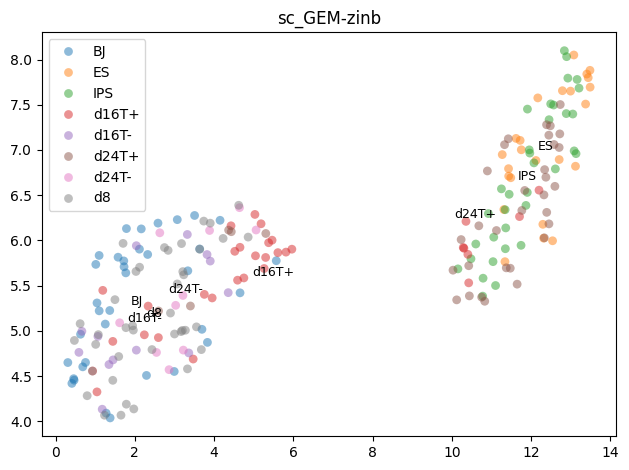

In [16]:
plot_embedding('sc_GEM', 'zinb', cell_stage)

ES, IPS, d24T+ are in one group.

Others are in the other group.

## PEA-STA

In [17]:
hg = load_graph('./data/PEA_STA', load_edges=False)

load_edges=False
Load nodes in 0.01 seconds.
Num nodes: 378, Num edges: NaN
Metadata: {'dataname': 'PEA_STA', 'filter_edge': False, 'num_cells': 210, 'num_genes': 166, 'num_omics': 2, 'num_nodes': 378, 'orig_edges': 34860, 'num_edges': 34860, 'omics_offset': 0, 'gene_offset': 2, 'cell_offset': 168, 'omics_dims': [141, 141], 'raw_data': {'expr': './data/PEA_STA/expression_data.csv', 'protein': './data/PEA_STA/protein_data.csv'}, 'cell_key': 'Cells ', 'normalize_stats': []}


In [21]:
cell_stage = hg.cell_names.str.split('_').map(lambda x: x[1:-1]).str.join('_')

{'NMI': 0.010575002361508505,
 'ARI': 0.00038467574590735396,
 'FMI': 0.3474292557138152}

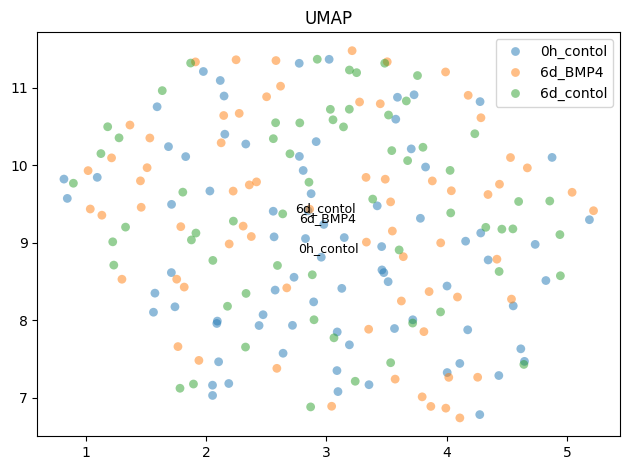

In [29]:
embedding_dir = f'./'
cell_embeddings = np.load(f'{embedding_dir}/mymodel_0.npy')
umap_visualize(cell_embeddings, cell_stage)
# plt.title(f'{data}-{loss}')